In [ ]:
import pandas as pd
import numpy as np
import glob

df = pd.concat([pd.read_csv(f) for f in glob.glob("csv/*.csv")], ignore_index=True)

df.groupby("tagValue")["amount"].sum().head(3)


,id,date,amount,note,tagKey,tagValue
0,MjAyMV8xX3ZhbGVyaW8udmF1ZGlAZ21haWwuY29t-M18xZ...,03/01/2021,28.73,AWS,amazon,Amazon
1,MjAyMV8xX3ZhbGVyaW8udmF1ZGlAZ21haWwuY29t-NF83M...,04/01/2021,2.89,Poste,tax,Tassa/Bolli
2,MjAyMV8xX3ZhbGVyaW8udmF1ZGlAZ21haWwuY29t-NV8zO...,05/01/2021,294.36,regalo,amazon,Amazon
3,MjAyMV8xX3ZhbGVyaW8udmF1ZGlAZ21haWwuY29t-Nl9jM...,06/01/2021,15.99,NaN,netflix,Netflix
4,MjAyMV8xX3ZhbGVyaW8udmF1ZGlAZ21haWwuY29t-N18xM...,07/01/2021,50.00,NaN,telephone-top-up,Ricarica Telefonica
...,...,...,...,...,...,...
5735,MjAyM18xMl92YWxlcmlvLnZhdWRpQGdtYWlsLmNvbQ==-M...,30/12/2023,7.39,esselunga desio,super-market,Spesa
5736,MjAyM18xMl92YWxlcmlvLnZhdWRpQGdtYWlsLmNvbQ==-M...,30/12/2023,15.00,NaN,bar,Bar
5737,MjAyM18xMl92YWxlcmlvLnZhdWRpQGdtYWlsLmNvbQ==-M...,31/12/2023,54.97,corrente,bill,Bolletta
5738,MjAyM18xMl92YWxlcmlvLnZhdWRpQGdtYWlsLmNvbQ==-M...,31/12/2023,22.70,NaN,pharmacy,Farmacia


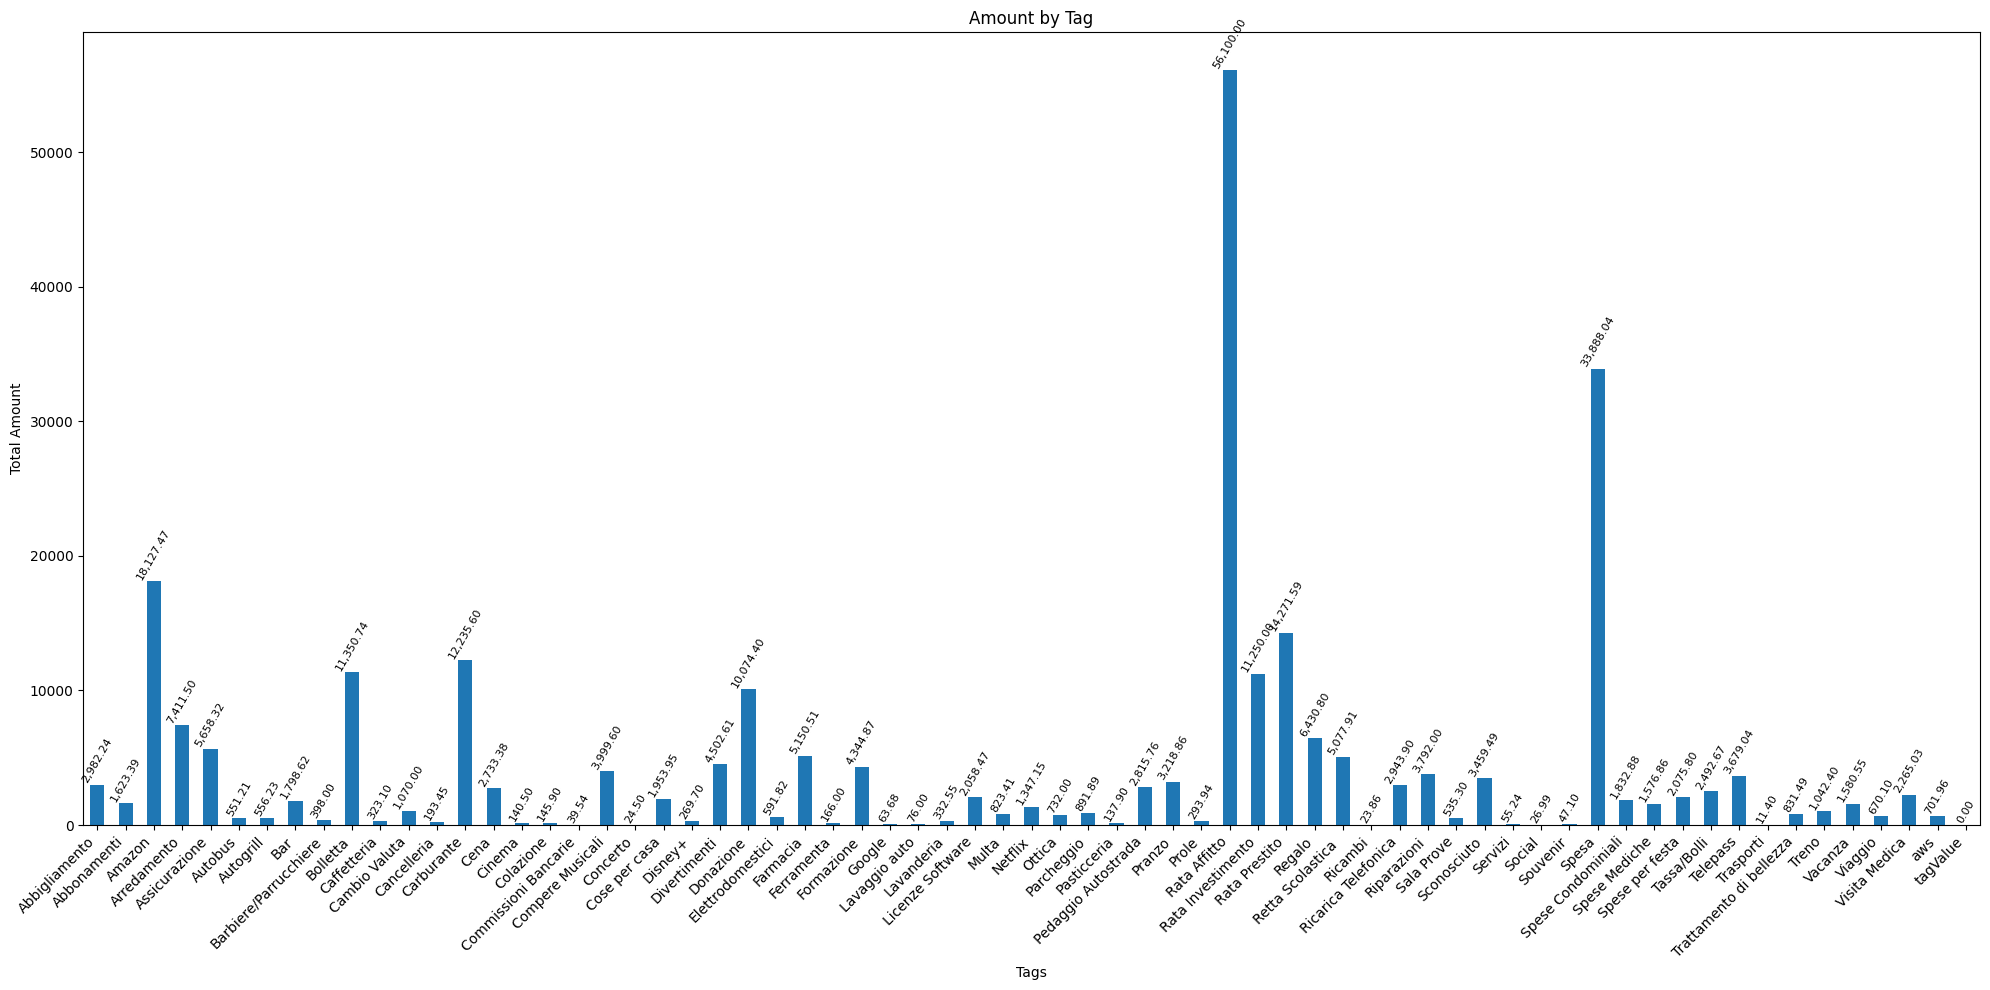

In [63]:
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt

df = pd.concat([pd.read_csv(f) for f in glob.glob("csv/*.csv")], ignore_index=True)

df["amount"] = pd.to_numeric(df["amount"], errors="coerce")

grouped = df.groupby("tagValue")["amount"].sum()


# Plot
plot = grouped.plot(
    kind="bar",
    figsize=(20, 10),
    title="Amount by Tag",
    xlabel="Tags",
    ylabel="Total Amount",
)  # or "pie", "line", etc.

for bar in plot.patches:
    plot.text(
        bar.get_x() + bar.get_width() / 2,  # X position
        bar.get_height(),                    # Y position
        f"{bar.get_height():,.2f}",          # Format the label (2 decimals)
        ha='center', 
        va='bottom', fontsize=8, rotation=60
    )
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

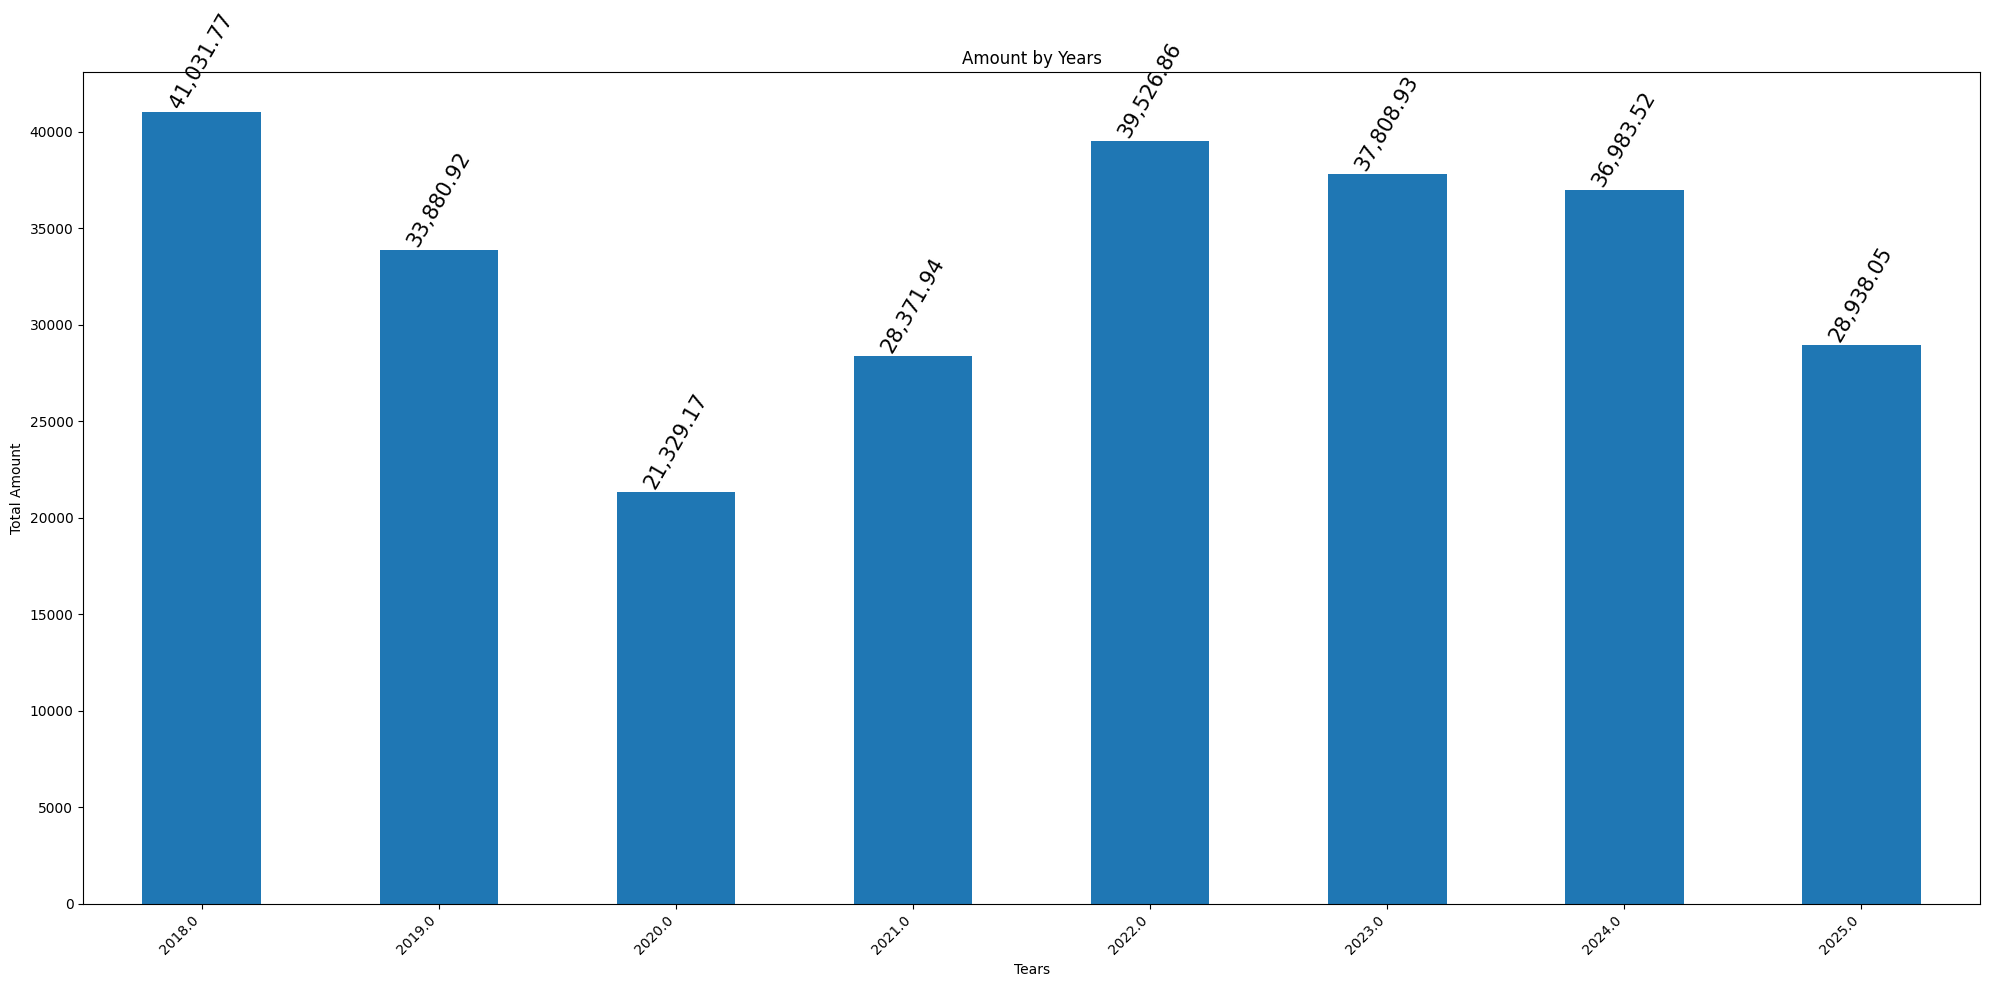

In [28]:
import pandas as pd
import glob
import matplotlib.pyplot as plt

df = pd.concat([pd.read_csv(f) for f in glob.glob("csv/*.csv")], ignore_index=True)
df["amount"] = pd.to_numeric(df["amount"], errors="coerce")

df["iso-date"] = pd.to_datetime(
    df["date"], format="%d/%m/%Y", errors="coerce"
).dt.strftime("%Y-%m-%d")

df["year"] = pd.to_datetime(df["date"], format="%d/%m/%Y", errors="coerce").dt.year
df["mount"] = pd.to_datetime(df["date"], format="%d/%m/%Y", errors="coerce").dt.month


# Plot
plot = df.groupby("year")["amount"].sum().plot(
    kind="bar",
    figsize=(20, 10),
    title="Amount by Years",
    xlabel="Tears",
    ylabel="Total Amount",
)  # or "pie", "line", etc.

for bar in plot.patches:
    plot.text(
        bar.get_x() + bar.get_width() / 2,  # X position
        bar.get_height(),  # Y position
        f"{bar.get_height():,.2f}",  # Format the label (2 decimals)
        ha="center",
        va="bottom",
        fontsize=15,
        rotation=60,
    )
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()